# Predicting Student Health Risk — v5: LightGBM + CatBoost Ensemble
### Kaggle Playground Series S6E7

**Recap:**
- v2 LightGBM (untuned): CV 0.94907, leaderboard 0.94979
- v3 LightGBM (tuned): CV 0.94953, leaderboard **0.95011**
- v4 CatBoost: CV 0.94902

**What this notebook does:**
1. Loads the **out-of-fold (OOF)** probabilities from both v3 (LightGBM) and v4 (CatBoost) —
   these are honest, held-out predictions on the training set.
2. Searches for the best blend weight `w` (from 0 = pure CatBoost to 1 = pure LightGBM) by
   checking balanced accuracy on the OOF predictions — this tells us the *真* best blend
   **without touching the test set**, so we're not fooling ourselves.
3. Applies that same weight to blend the **test** probabilities from both models.
4. Saves the final `submission.csv`.

**Setup needed before running:** upload `lightgbm_oof_proba.npy`, `lightgbm_test_proba.npy`,
`catboost_oof_proba.npy`, `catboost_test_proba.npy`, and `y_true_enc.npy` as a Kaggle Dataset
(or attach them directly if running in the same session), and set `PROBA_DIR` below to point to
wherever they land (e.g. `/kaggle/input/your-dataset-name`).

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

# UPDATE this path to wherever you uploaded the .npy files (e.g. as a Kaggle Dataset)
PROBA_DIR = "/kaggle/input/datasets/vikraamkumards/health-risk-oof-files"
DATA_DIR = "/kaggle/input/competitions/playground-series-s6e7"


In [2]:
import os
print(os.listdir(PROBA_DIR))

['lightgbm_test_proba.npy', 'catboost_test_proba.npy', 'catboost_oof_proba.npy', 'lightgbm_oof_proba.npy', 'y_true_enc.npy']


## 1. Load OOF + test probabilities from both models

In [3]:
lgbm_oof = np.load(f"{PROBA_DIR}/lightgbm_oof_proba.npy")
cat_oof = np.load(f"{PROBA_DIR}/catboost_oof_proba.npy")
y_true_enc = np.load(f"{PROBA_DIR}/y_true_enc.npy")

lgbm_test = np.load(f"{PROBA_DIR}/lightgbm_test_proba.npy")
cat_test = np.load(f"{PROBA_DIR}/catboost_test_proba.npy")

print("LightGBM OOF shape:", lgbm_oof.shape)
print("CatBoost OOF shape:", cat_oof.shape)
print("LightGBM test shape:", lgbm_test.shape)
print("CatBoost test shape:", cat_test.shape)

# Sanity check: each model's own OOF score should roughly match its earlier reported CV score
lgbm_oof_score = balanced_accuracy_score(y_true_enc, np.argmax(lgbm_oof, axis=1))
cat_oof_score = balanced_accuracy_score(y_true_enc, np.argmax(cat_oof, axis=1))
print(f"\nLightGBM OOF balanced accuracy: {lgbm_oof_score:.5f}  (expect ~0.94953)")
print(f"CatBoost OOF balanced accuracy:  {cat_oof_score:.5f}  (expect ~0.94902)")

LightGBM OOF shape: (690088, 3)
CatBoost OOF shape: (690088, 3)
LightGBM test shape: (295753, 3)
CatBoost test shape: (295753, 3)

LightGBM OOF balanced accuracy: 0.94959  (expect ~0.94953)
CatBoost OOF balanced accuracy:  0.94905  (expect ~0.94902)


## 2. Search for the best blend weight using OOF predictions

`w` is the weight on LightGBM; `(1-w)` goes to CatBoost. We sweep `w` from 0 to 1 and pick
whichever gives the best balanced accuracy on the OOF set — this is a fair, held-out estimate
of how a blend would perform, not just a guess.

In [4]:
weights = np.linspace(0, 1, 41)  # 0.00, 0.025, 0.05, ..., 1.00
results = []

for w in weights:
    blended_oof = w * lgbm_oof + (1 - w) * cat_oof
    score = balanced_accuracy_score(y_true_enc, np.argmax(blended_oof, axis=1))
    results.append((w, score))

results_df = pd.DataFrame(results, columns=["lgbm_weight", "oof_balanced_accuracy"])
best_row = results_df.loc[results_df["oof_balanced_accuracy"].idxmax()]

print(results_df.to_string(index=False))
print(f"\nBest LightGBM weight: {best_row['lgbm_weight']:.3f}")
print(f"Best OOF balanced accuracy: {best_row['oof_balanced_accuracy']:.5f}")
print(f"Compare to: LightGBM alone {lgbm_oof_score:.5f}, CatBoost alone {cat_oof_score:.5f}")

 lgbm_weight  oof_balanced_accuracy
       0.000               0.949046
       0.025               0.949061
       0.050               0.949074
       0.075               0.949085
       0.100               0.949104
       0.125               0.949136
       0.150               0.949157
       0.175               0.949154
       0.200               0.949182
       0.225               0.949193
       0.250               0.949258
       0.275               0.949277
       0.300               0.949298
       0.325               0.949338
       0.350               0.949356
       0.375               0.949343
       0.400               0.949365
       0.425               0.949378
       0.450               0.949382
       0.475               0.949404
       0.500               0.949404
       0.525               0.949404
       0.550               0.949431
       0.575               0.949444
       0.600               0.949440
       0.625               0.949456
       0.650               0

<Axes: title={'center': 'OOF Balanced Accuracy vs. LightGBM Blend Weight'}, xlabel='lgbm_weight'>

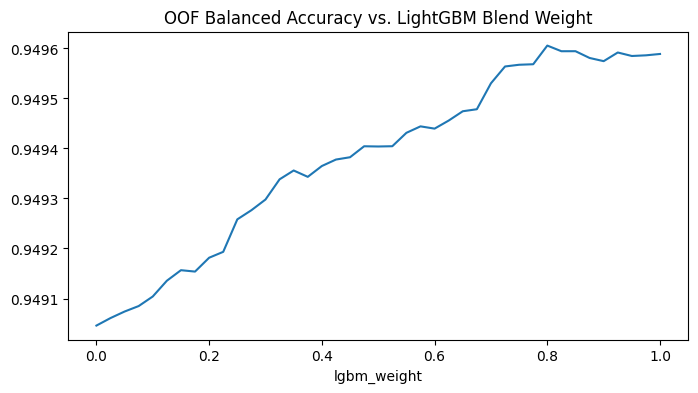

In [5]:
results_df.plot(x="lgbm_weight", y="oof_balanced_accuracy", figsize=(8,4),
                 title="OOF Balanced Accuracy vs. LightGBM Blend Weight", legend=False)

## 3. Apply the best weight to the test set and save submission

**Important interpretation note:** if the best weight found is very close to 0 or 1 (e.g.
`w=0.95` or `w=0.05`), that means the blend isn't really helping — one model is just
dominating. In that case, it's fine (and simpler) to just submit that model alone rather than
bothering with a blend. A genuinely useful blend usually has its best weight somewhere in the
middle (e.g. 0.4-0.7), showing both models are contributing.

In [6]:
best_w = best_row["lgbm_weight"]

blended_test = best_w * lgbm_test + (1 - best_w) * cat_test
final_preds_enc = np.argmax(blended_test, axis=1)

# Recreate the label encoder mapping (at-risk=0, fit=1, unhealthy=2, alphabetical order)
target_encoder = LabelEncoder()
target_encoder.classes_ = np.array(["at-risk", "fit", "unhealthy"])
final_preds = target_encoder.inverse_transform(final_preds_enc)

test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

submission = pd.DataFrame({"id": test["id"], "health_condition": final_preds})
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)

submission.to_csv("submission.csv", index=False)
print(f"Used blend weight (LightGBM): {best_w:.3f}")
print(pd.Series(final_preds).value_counts())
submission.head()

Used blend weight (LightGBM): 0.800
at-risk      239852
unhealthy     34124
fit           21777
Name: count, dtype: int64


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


## Next steps

1. **Submit this to Kaggle** and compare against your current best (v3: leaderboard 0.95011).
2. If the ensemble OOF score beat both individual OOF scores meaningfully, it's very likely
   to also beat them on the leaderboard — ensembling gains tend to transfer well since it's
   not overfitting to any specific split.
3. If the gain is tiny or the best weight was near 0/1, that tells you these two models are
   too similar (or one is just weaker) to gain much from blending — the next real lever would
   be **feature engineering** or trying a genuinely different 3rd model.
4. You could also try **rank averaging** instead of probability averaging as a variant, or
   blend at the **prediction level via majority vote** — but probability blending (what we did
   here) is usually the strongest simple ensembling method.

Keep versioning: this is v5 (LightGBM + CatBoost ensemble).